#### The objective of this process is to provide necessary data to respond to the research question:
***Where is an escalation of violence predicted***

In [19]:
import os
import sys

# Get the current working directory
current_directory = os.getcwd()

# Print the current working directory
print("The current Working Directory is:", current_directory)

# Get the path to the base directory (VIEWS_FAO_index)
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
print(f'The base directory will be set to: {base_dir}')

# Add the base directory to sys.path
sys.path.insert(0, base_dir)

The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index


In [20]:
from ingester3 import *
# delte this is temporary--
from src.utils.functions_for_graphics.individual_graphics.map_helper.manipulate_tables_for_mapping import calculate_histogram_data


from src.utils.universal_functions.setup.generate_base_file import give_primary_frame
from src.utils.universal_functions.setup.generate_percentiles import get_percentiles
from src.utils.universal_functions.setup.define_scale import select_scale

from src.utils.functions_for_return_periods.insurance_products_for_RP import insurance_files

from src.utils.universal_functions.setup.build_directory import float_to_custom_string, ensure_directory_exists


#Functions for graphics:
from src.utils.functions_for_graphics.construct_custom_symbology import user_defined_colormap, display_percentile_color_table, assign_color_to_zero_values, process_and_merge_return_periods


from src.utils.functions_for_graphics.individual_graphics.map_helper.manipulate_tables_for_mapping import clean_info_dataframe, query_and_sort_annual_table, provide_values_at_input_return_periods, retrieve_geodataframe, define_year_to_map, query_geodataframe

from src.utils.functions_for_graphics.individual_graphics.image_annual_returnperiod_table import image_save_returnperiodtable
from src.utils.functions_for_graphics.individual_graphics.image_annual_returnperiod_lineplot import plot_histogram_with_lineplot_4
from src.utils.functions_for_graphics.individual_graphics.image_annual_summary_table import plot_and_colorize_annual_table
from src.utils.functions_for_graphics.individual_graphics.image_map_for_Ei import image_save_map_E_i

#Mapping structure:
from src.utils.functions_for_graphics.layout_formats.event_cat_rp import map_event_cat_rp
from src.utils.functions_for_graphics.layout_formats.summary_of_top_years import map_top_years
#from src.utils.functions_for_graphics.layout_formats.Layout_single_method_option1 import mapped_option1


#functions for all methods
from src.utils.universal_functions.FAO_table_formatting.generate_output_tables import generate_and_give_info_dataframe, append_return_periods_to_annual_table

## Construct ***Historical*** Dataframe
#### Provide user inputs to caputure a dataframe for `Recent Conflict History`

In [12]:
data = give_primary_frame('Fatalities_fao_pgm', 'cm_properties', 2023, 2026)

100%|██████████| 40.0M/40.0M [00:02<00:00, 19.2MB/s]


Queryset Fatalities_fao_pgm read successfully 
Queryset cm_properties read successfully 


/Users/gbenz/miniforge3/envs/viewser/lib/python3.11/site-packages/ingester3/scratch.py:31: UserWarning: No database connection! Will try to use cache for read-only ops as much as I can
  warnings.warn("No database connection! Will try to use cache for read-only ops as much as I can")


['month_id', 'pg_id', 'C_start_year', 'C_end_year', 'pop_gpw_sum', 'country_name', 'ged_sb', 'ged_ns', 'ged_os', 'year', 'fatalities_sum', 'country_id']


#### Assign `month` and `date` columns

- Subsect state based conflict `ged_sb` that is not zero
- Identify the most recent date of reported conflict events and save to the variable `latest_date`

In [13]:
from ingester3.extensions import *
data['month'] = data.m.month

# Create a date column with the first day of each month
data['date'] = pd.to_datetime(
    data['year'].astype(str) + '-' + data['month'].astype(str).str.zfill(2) + '-01'
)
# Filter rows where ged_sb is non-zero
mask = data['ged_sb'] != 0
latest_date = data.loc[mask, 'date'].max()

print("Latest date with non-zero ged_sb:", latest_date)

/Users/gbenz/miniforge3/envs/viewser/lib/python3.11/site-packages/ingester3/scratch.py:31: UserWarning: No database connection! Will try to use cache for read-only ops as much as I can
  warnings.warn("No database connection! Will try to use cache for read-only ops as much as I can")


Latest date with non-zero ged_sb: 2025-01-01 00:00:00


## Reference VIEWS ***Predictions*** Dataframe

In [27]:
import pandas as pd

# Define the URL of the CSV file
url = 'https://viewsforecasting.org/wp-content/uploads/fatalities002_2024_12_t01_pgm.csv'

# Read the CSV file into a DataFrame
predictions = pd.read_csv(url)
# Optional: Display the first few rows to verify

predictions['month'] = predictions.m.month

# Extract the month as a two-digit string and the year as an integer
predictions['month'] = predictions['month'].astype(int).astype(str).str.zfill(2)
predictions['year'] = predictions.m.year
predictions['year_id'] = predictions.m.year

# Create a date column with the first day of each month
predictions['date'] = pd.to_datetime(
    predictions['year'].astype(str) + '-' + predictions['month'].astype(str).str.zfill(2) + '-01'
)

In [25]:
predictions['c_id'] = predictions.pgy.c_id
#predictions['country_name'] = predictions.c.name
print(predictions.head())

KeyboardInterrupt: 

***We want to sum the fatalities over the next year***
**The standard output is a monthly dataframe** Lets convert this to annual:

***Reference the date from the predictions dataframe for one month and one year ahead***

In [28]:
# Ensure 'date' column is in datetime format
predictions['date'] = pd.to_datetime(predictions['date'])

# Filter data for the first year (2025)
df_first_year = predictions[(predictions['date'] >= '2025-01-01') & (predictions['date'] <= '2025-12-01')]

# Aggregate the sum of main_mean_ln, main_mean, and main_dich by pg_id
df_annual = df_first_year.groupby("pg_id", as_index=False).agg({
    "main_mean_ln": "sum",
    "main_mean": "sum",
    "main_dich": "sum"
})

df_first_three_months = predictions[predictions['date'] <= '2025-03-01']

# Aggregate the sum of main_mean_ln, main_mean, and main_dich by pg_id
df_three_month_sum = df_first_three_months.groupby("pg_id", as_index=False).agg({
    "main_mean_ln": "sum",
    "main_mean": "sum",
    "main_dich": "sum"
})

# Assign the last date of the year to the 'date' column
df_annual["date"] = pd.to_datetime("2025-12-01")

# Display the result
print(df_annual)

        pg_id  main_mean_ln  main_mean  main_dich       date
0       62356        0.0050     0.0050     0.0781 2025-12-01
1       79599        0.0028     0.0028     0.0776 2025-12-01
2       79600        0.0035     0.0035     0.0777 2025-12-01
3       79601        0.0027     0.0027     0.0775 2025-12-01
4       80317        0.0049     0.0049     0.0781 2025-12-01
...       ...           ...        ...        ...        ...
13105  190496        0.0695     0.0699     0.1025 2025-12-01
13106  190507        0.0026     0.0026     0.0773 2025-12-01
13107  190508        0.0026     0.0026     0.0773 2025-12-01
13108  190510        0.0026     0.0026     0.0775 2025-12-01
13109  190511        0.0030     0.0030     0.0775 2025-12-01

[13110 rows x 5 columns]


In [51]:
import pandas as pd

historical_monthly_one_year = pd.read_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/Syria_one_year_monthly_date_sum.csv')

syria_2024 = pd.read_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/Syia_All_PGY.csv')

syria = syria_2024[['pg_id']].drop_duplicates()

df_first_year

syria_one_year_predictions = syria.merge(df_first_year, on="pg_id", how="left")

# Aggregate the sum of main_mean_ln, main_mean, and main_dich by pg_id
syria_one_year_predictions_sum = syria_one_year_predictions.groupby("date", as_index=False).agg({
    "main_mean": "sum",

})


# Ensure both dataframes have the same column name for merging
df1 = syria_one_year_predictions_sum.rename(columns={'main_mean': 'value'})
df2 = historical_monthly_one_year.rename(columns={'ged_sb': 'value'})

# Ensure both DataFrames have 'date' in datetime format
df1['date'] = pd.to_datetime(df1['date'])
df2['date'] = pd.to_datetime(df2['date'])

# Concatenate along rows while keeping all dates
df_combined = pd.concat([df1, df2], ignore_index=True)

# Rename columns back to original names for clarity
df_combined = df_combined.rename(columns={'value': 'data'})
df_combined = df_combined.sort_values(by='date').reset_index(drop=True)

# Display the combined DataFrame
print(df_combined)


#combined_one_year_historical_one_year_predictions = historical_monthly_one_year.merge(syria_one_year_predictions, on='pg_id', how='intersect')

#print(combined_one_year_historical_one_year_predictions.head())

#df_first_year

# df_first_year['c_id'] = df_first_year.pgy.c_id
# #predictions['country_name'] = predictions.c.name
# print(df_first_year.head())
df_combined = df_combined[df_combined['date'] >= '2024-01-01']

         date       data  Unnamed: 0
0  2023-01-01   103.0000         0.0
1  2023-02-01   155.0000         1.0
2  2023-03-01   122.0000         2.0
3  2023-04-01   104.0000         3.0
4  2023-05-01    54.0000         4.0
5  2023-06-01    82.0000         5.0
6  2023-07-01    73.0000         6.0
7  2023-08-01   181.0000         7.0
8  2023-09-01   125.0000         8.0
9  2023-10-01   282.0000         9.0
10 2023-11-01   156.0000        10.0
11 2023-12-01    97.0000        11.0
12 2024-01-01   134.0000        12.0
13 2024-02-01   184.0000        13.0
14 2024-03-01   289.0000        14.0
15 2024-04-01   140.0000        15.0
16 2024-05-01   113.0000        16.0
17 2024-06-01   124.0000        17.0
18 2024-07-01    51.0000        18.0
19 2024-08-01    97.0000        19.0
20 2024-09-01   148.0000        20.0
21 2024-10-01   238.0000        21.0
22 2024-11-01   650.0000        22.0
23 2024-12-01   486.0000        23.0
24 2025-01-01  1014.2834         NaN
25 2025-02-01   711.9510         NaN
2

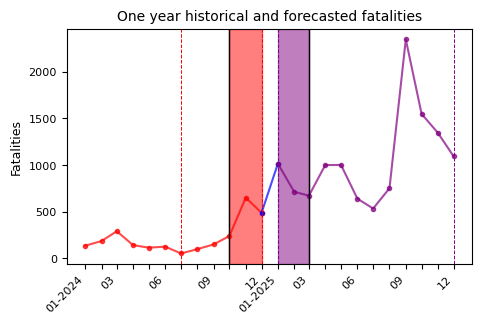

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert mm to inches for Matplotlib (1 inch = 25.4 mm)
fig_width = 125 / 25.4  # Convert to inches
fig_height = 85 / 25.4  # Convert to inches

# Ensure date column is in datetime format
df_combined["date"] = pd.to_datetime(df_combined["date"])

# Choose a column to plot on the y-axis
value_column = "data"  # Change this to your actual column name

# Extract year and month
df_combined["year"] = df_combined["date"].dt.year
df_combined["month_num"] = df_combined["date"].dt.strftime("%m")  # Extracts month in 2-digit format
df_combined["month_year"] = df_combined["date"].dt.strftime("%m-%Y")  # '01-YYYY' format for January
df_combined["month_str"] = df_combined["date"].dt.strftime("%m")  # Numeric month labels

# Custom x-axis labels: January gets '01-YYYY', others get 'MM' format every 3 months
df_combined["x_labels"] = df_combined.apply(
    lambda row: row["month_year"] if row["month_num"] == "01" else (row["month_str"] if int(row["month_num"]) % 3 == 0 else ""), 
    axis=1
)

# Define date ranges
start_2024 = pd.to_datetime("2024-01-01")
end_2024 = pd.to_datetime("2024-12-01")
start_2025 = pd.to_datetime("2025-01-01")

# Subset data by date ranges
df_2024 = df_combined[df_combined["date"] <= end_2024]  # 2024 (red)
df_transition = df_combined[(df_combined["date"] >= end_2024) & (df_combined["date"] <= start_2025)]  # Dec 2024 - Jan 2025 (blue)
df_2025 = df_combined[df_combined["date"] >= start_2025]  # Beyond Jan 2025 (purple)

# Create the figure
plt.figure(figsize=(fig_width, fig_height))

# Line plots with different colors based on date ranges
plt.plot(df_2024["date"], df_2024[value_column], marker='o', markersize=3, linestyle='-', color='r', alpha=0.7, label="2024")
plt.plot(df_transition["date"], df_transition[value_column], marker='o', markersize=3, linestyle='-', color='b', alpha=0.7, label="Dec 2024 - Jan 2025")
plt.plot(df_2025["date"], df_2025[value_column], marker='o', markersize=3, linestyle='-', color='purple', alpha=0.7, label="2025+")

# Set custom x-ticks with smaller labels
plt.xticks(df_combined["date"], df_combined["x_labels"], rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)  # Make y-axis labels smaller

# Add shaded regions
plt.axvspan(pd.to_datetime("2024-10-01"), pd.to_datetime("2024-12-01"), color='red', alpha=0.5)  # Red shaded region
plt.axvspan(pd.to_datetime("2025-01-01"), pd.to_datetime("2025-03-01"), color='purple', alpha=0.5)  # Purple shaded region

# Add vertical reference lines
plt.axvline(pd.to_datetime("2024-10-01"), color='black', linestyle='-', linewidth=1, label="Oct 2024")
plt.axvline(pd.to_datetime("2024-12-01"), color='red', linestyle='--', linewidth=0.7, label="Dec 2024")
plt.axvline(pd.to_datetime("2025-01-01"), color='purple', linestyle='--', linewidth=0.7, label="Jan 2025")
plt.axvline(pd.to_datetime("2025-03-01"), color='black', linestyle='-', linewidth=1, label="Mar 2025")

plt.axvline(pd.to_datetime("2024-07-01"), color='red', linestyle='--', linewidth=0.7, label="Jul 2024")
plt.axvline(pd.to_datetime("2025-12-01"), color='purple', linestyle='--', linewidth=0.7, label="Dec 2025")

# Format labels
plt.ylabel("Fatalities", fontsize=9)
plt.title("One year historical and forecasted fatalities", fontsize=10)

# Improve layout
plt.tight_layout()

# Show plot
plt.show()



In [44]:
df_combined.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/combined_syria_one_year_history_predictions.csv')

In [18]:
df_first_year.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/predictions_global_one_year_monthly_predictions.csv')

df_three_month_sum.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/predictions_global_three_month_sum.csv')

In [71]:
import numpy as np

# First, get the unique dates (ensuring they're in datetime format)
unique_dates = pd.to_datetime(predictions['date'].unique())

# Sort the dates; np.sort returns a sorted numpy array
sorted_dates = np.sort(unique_dates)

# The most recent date will be the last element in the sorted array
most_recent_date = sorted_dates[0]
year_prediction = sorted_dates[11]

print("Most recent date:", most_recent_date)
print("One year prediction date:", year_prediction)

subset_one_month_predictions = predictions[predictions['date'] == most_recent_date]

subset_one_year_predictions = predictions[predictions['date'] == year_prediction]



Most recent date: 2025-01-01T00:00:00.000000000
One year prediction date: 2025-12-01T00:00:00.000000000


In [ ]:
# Export dataframes to csv files:
subset_one_month_predictions.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/one_month_predictions.csv')
subset_one_year_predictions.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/one_year_predictions.csv')

#### Having identified the date derived from the most recent VIEWS Predictions
***Reference the date from recent historical data for one, three, and six months prior to the predictions***


In [72]:
import pandas as pd

# Define your start time variable (replacing latest_date)
start_date = pd.to_datetime(most_recent_date)

# Subtract 1, 3, and 6 months using DateOffset
date_1_month_behind = start_date - pd.DateOffset(months=1)
date_3_months_behind = start_date - pd.DateOffset(months=3)
date_6_months_behind = start_date - pd.DateOffset(months=6)

# Display the computed dates
print("1 month behind:", date_1_month_behind)
print("3 months behind:", date_3_months_behind)
print("6 months behind:", date_6_months_behind)

# Now, subset the DataFrame for each computed date
subset_one_month_recent = data[data['date'] == date_1_month_behind]
subset_three_month_recent = data[data['date'] == date_3_months_behind]
subset_six_month_recent = data[data['date'] == date_6_months_behind]

1 month behind: 2024-12-01 00:00:00
3 months behind: 2024-10-01 00:00:00
6 months behind: 2024-07-01 00:00:00


In [ ]:
# Export dataframes to csv files:
subset_one_month_recent.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/one_month_recent.csv')
subset_three_month_recent.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/three_month_recent.csv')
subset_six_month_recent.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/six_month_recent.csv')

### Evaluate ***Escalation***
#### Here we will difference the ***Predictions*** from the ***observed recent conflict history***

In [78]:
# Define the prediction field to evaluate ['main_mean','main_mean_ln', 'main_dich']

prediction_field = 'main_mean'

In [81]:
# ----------------------------------------------------------------------------------------------------------
# Compare one month prediction to most recent observed historical month
# ----------------------------------------------------------------------------------------------------------
one_month_rec__one_month_pred = pd.merge(subset_one_month_recent, subset_one_month_predictions, on='pg_id')

one_month_rec__one_month_pred['one_month_dif'] =  one_month_rec__one_month_pred[prediction_field] - one_month_rec__one_month_pred['ged_sb'] 
# ----------------------------------------------------------------------------------------------------------
# Define necessary columns from 'one_month_rec__one_month_pred':
# ----------------------------------------------------------------------------------------------------------
one_month_rec__one_month_pred__organized = one_month_rec__one_month_pred[['pg_id', 'ged_sb', prediction_field, 'one_month_dif']]
# ----------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------


# ----------------------------------------------------------------------------------------------------------
# Compare one year prediction to most recent observed historical month
# ----------------------------------------------------------------------------------------------------------
one_month_rec__one_year_pred = pd.merge(subset_one_month_recent, subset_one_year_predictions, on='pg_id')

one_month_rec__one_year_pred['one_year_dif'] = one_month_rec__one_year_pred[prediction_field]- one_month_rec__one_year_pred['ged_sb'] 
# ----------------------------------------------------------------------------------------------------------
# Define necessary columns from 'one_month_rec__one_month_pred':
# ----------------------------------------------------------------------------------------------------------
one_month_rec__one_year_pred__organized = one_month_rec__one_year_pred[['pg_id', 'one_year_dif']]
# ----------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------


# ----------------------------------------------------------------------------------------------------------
# Merge predicted one month with one year
# ----------------------------------------------------------------------------------------------------------
combined_predictions = pd.merge(one_month_rec__one_year_pred__organized, one_month_rec__one_month_pred__organized, on='pg_id')
# ----------------------------------------------------------------------------------------------------------
display(combined_predictions.head(10))
# ----------------------------------------------------------------------------------------------------------


# ----------------------------------------------------------------------------------------------------------
# Country Year Summary for one month predicted change
# ----------------------------------------------------------------------------------------------------------
cm_one_month = one_month_rec__one_month_pred.groupby('country_name', as_index=False)[['one_month_dif', 'ged_sb', prediction_field]].sum()
cm_one_year = one_month_rec__one_year_pred.groupby('country_name', as_index=False)['one_year_dif'].sum()
# ----------------------------------------------------------------------------------------------------------
# Define necessary columns from 'one_month_rec__one_month_pred':
# ----------------------------------------------------------------------------------------------------------
combined_country = pd.merge(cm_one_year, cm_one_month, on='country_name')
# ----------------------------------------------------------------------------------------------------------
combined_country = combined_country[['country_name', 'ged_sb', prediction_field, 'one_month_dif', 'one_year_dif']]
# ----------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------
display(combined_country.head(100))



,pg_id,one_year_dif,ged_sb,main_mean,one_month_dif
0,62356,0.0002,0.0,0.0001,0.0001
1,79599,0.0003,0.0,0.0001,0.0001
2,79600,0.0004,0.0,0.0002,0.0002
3,79601,0.0003,0.0,0.0002,0.0002
4,80317,0.0005,0.0,0.0002,0.0002
5,80318,0.0005,0.0,0.0005,0.0005
6,80319,0.0003,0.0,0.0001,0.0001
7,80320,0.0003,0.0,0.0002,0.0002
8,80321,0.0004,0.0,0.0001,0.0001
9,80322,0.0004,0.0,0.0001,0.0001


,country_name,ged_sb,main_mean,one_month_dif,one_year_dif
0,Afghanistan,0.0,31.7924,31.7924,62.6568
1,Algeria,0.0,0.1713,0.1713,0.2766
2,Angola,0.0,0.2853,0.2853,0.4283
3,Armenia,0.0,0.1159,0.1159,0.3442
4,Azerbaijan,0.0,0.1925,0.1925,0.6412
5,Bahrain,0.0,0.0113,0.0113,0.0143
6,Benin,15.0,3.3144,-11.6856,-10.8443
7,Botswana,0.0,0.0000,0.0000,0.0027
8,Bulgaria,0.0,0.0014,0.0014,0.0178
9,Burkina Faso,27.0,75.6536,48.6536,104.0333


In [82]:
# Export dataframes to csv files:

one_month_rec__one_month_pred.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/one_month_change.csv')
one_month_rec__one_year_pred.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/one_year_change.csv')

combined_predictions.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/combined_predictions.csv')
combined_country.to_csv('/Users/gbenz/Documents/VIEWS_FAO_index/data/processed/country_change.csv')
